In [1]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import kagglehub
import keras.backend as K
from matplotlib import rcParams
import matplotlib.pyplot as plt
from keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, TimeDistributed,
    Permute, Reshape, LSTM, Dense, Dropout, Lambda, Flatten
)
from glob import glob as gg
from pyspark.sql import SparkSession
from tensorflow.data import AUTOTUNE
from keras.callbacks import ModelCheckpoint
from keras.models import load_model, Model, Sequential
from pyspark.sql.functions import col, udf, aggregate as agg, max, min, filter
from pyspark.sql.types import StringType, ArrayType, IntegerType, FloatType

2025-04-29 11:58:52.181311: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 11:58:52.298372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-29 11:58:52.326621: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-29 11:58:52.335729: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-29 11:58:52.472378: I tensorflow/core/platform/cpu_feature_guar

In [235]:
dpi = 200 # 200-300 as per guidelines
maxpix = 670  # max pixels of plot
width = maxpix / dpi  # max allowed width
rcParams.update({'axes.labelsize': 'large', 'axes.titlesize': 'x-large',  # the size of labels and title
                 'xtick.labelsize': 'large', 'ytick.labelsize': 'large',  # the size of the axes ticks
                 'legend.fontsize': 'x-small', 'legend.frameon': False,  # legend font size, no frame
                 'legend.facecolor': 'none', 'legend.handletextpad': 0.25,
                 # legend no background colour, separation from label to point
                 'font.serif': ['Arial'],  # default fonts to try and use
                 'font.family': 'serif',  # use serif fonts
                 'mathtext.fontset': 'cm', 'mathtext.default': 'regular',  # if in math mode, use these
                 'figure.figsize': [0.4 * width,  (0.3 * width)], 'figure.dpi': dpi,
                 
                'text.color' : "black", 'axes.labelcolor' : "black",'axes.facecolor': 'white',
                 'xtick.color':'black', 'ytick.color':'black', 'figure.facecolor':'none',
                 
                 # the figure size in inches and dots per inch
                 'lines.linewidth': .75,  # width of plotted lines
                 'xtick.top': True, 'ytick.right': True,  # ticks on right and top of plot
                 'xtick.minor.visible': True, 'ytick.minor.visible': True,  # show minor ticks
                 'text.usetex': False, 'xtick.labelsize':'large',
                 'ytick.labelsize':'large'})

In [37]:
spark = SparkSession.builder \
            .appName("LSTMJsonExtractor") \
            .config("spark.driver.port", "8887") \
            .config("spark.blockManager.port", "8886") \
            .config("spark.driver.memory",  "32g") \
            .config("spark.executor.memory","32g") \
            .config("spark.driver.maxResultSize", "32g") \
            .getOrCreate()

In [38]:
# archive = kagglehub.dataset_download("aidapearson/ocr-data")# Cluster

archive = "/home2/va23abb/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36"

In [39]:
# gg(f"{archive}/*")

# archive

df = spark.read.parquet("images_small_dims.parquet")

df.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|               latex|    full_latex_chars| visible_latex_chars|    visible_char_map|width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|     true_file_paths|           png_masks|
+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------

In [40]:
df2 = df.select("true_file_paths", "visible_char_map")

In [6]:
with open(f"{archive}/extras/visible_char_map.json", "r") as file:
    symbols_index = json.load(file)

In [12]:
total_len = df2.count()

train_len = int(0.7 * total_len)
test_len = int(total_len * 0.1)
val_len = total_len - train_len - test_len

assert train_len + test_len + val_len == total_len

# train_len, test_len, val_len, total_len

In [13]:
def generator():
    for row in df2.select("true_file_paths", "visible_char_map") \
        .toLocalIterator():
        path = row["true_file_paths"]
        seq = row["visible_char_map"]
        seq = np.array(seq, dtype = np.int32)
        if path is None:
            continue
        yield path, seq

In [ ]:
def process_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.image.resize(img, [32, 128])
    img = img / 255.0
    label = tf.cast(label, tf.int32)
    return img, label

In [15]:
def prepare(dataset, batch_size = 8):
	return (
		dataset
		.map(process_image, num_parallel_calls = AUTOTUNE)
		.padded_batch(
			batch_size,
			padded_shapes = ([64, 256, 3], [64]),
			padding_values = (0.0, 0)
		)
		.prefetch(AUTOTUNE)
	)

In [ ]:
raw_ds = tf.data.Dataset.from_generator(
	generator,
    output_signature = (
        tf.TensorSpec(shape = (), dtype = tf.string),
        tf.TensorSpec(shape = (None, ), dtype = tf.int32)
	)
)

2025-04-26 12:41:33.172402: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:17:00.0, compute capability: 8.0
2025-04-26 12:41:33.174507: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79196 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2025-04-26 12:41:33.175992: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79196 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0
2025-04-26 12:41:33.178041: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 79196 MB memory:  -> device: 3, name: NVIDIA A100 80GB PCIe, pci bu

In [17]:
raw_ds = raw_ds.shuffle(buffer_size = total_len, seed = 42)

In [18]:
train_ds = raw_ds.take(train_len)

rest_ds = raw_ds.skip(train_len)

test_ds = rest_ds.skip(test_len)

val_ds = rest_ds.take(test_len)

In [19]:
train_ds = prepare(train_ds, batch_size = 64)
test_ds = prepare(test_ds, batch_size = 64)
val_ds = prepare(val_ds, batch_size = 64)

In [20]:
len(symbols_index)

91

In [ ]:
img_h, img_w, n_ch = 64, 256, 3
n_classes = 91
max_timesteps = 64

input = Input(shape = (img_h, img_w, n_ch), name = "image_input")

x = Conv2D(filters = 32, kernel_size = 3, activation = "relu", padding = "same", name = "first_conv")(input)
x = BatchNormalization(name = "first_batch_norm")(x)
x = MaxPooling2D(pool_size = 2, name = "first_pool")(x)

x = Conv2D(filters = 64, kernel_size = 3, activation="relu", padding = "same", name = "second_conv")(x)
x = BatchNormalization(name = "second_batch_norm")(x)
x = MaxPooling2D(pool_size = 2, name = "second_pool")(x)

x = Conv2D(filters = 128, kernel_size = 3, activation="relu", padding = "same", name = "third_conv")(x)
x = BatchNormalization(name = "third_batch_norm")(x)

x = Conv2D(filters = 64, kernel_size = 3, activation="relu", padding = "same", name = "fourth_conv")(x)
x = BatchNormalization(name = "fourth_batch_norm")(x)

x = Conv2D(filters = 32, kernel_size = 3, activation="relu", padding = "same", name = "fifth_conv")(x)
x = BatchNormalization(name = "fifth_batch_norm")(x)

x = Permute((2,1,3))(x)
time_steps = x.shape[1]
features   = x.shape[2] * x.shape[3]
x = Reshape((time_steps, features))(x)

x = LSTM(128, return_sequences = True, name = "lstm")(x)

output = Dense(units = n_classes, activation = "softmax")(x)

model = Model(inputs = input, outputs = output)

In [9]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 64, 256, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_conv (Conv2D)             │ (None, 64, 256, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_batch_norm                │ (None, 64, 256, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_pool (MaxPooling2D)       │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ second_conv (Conv2D)            │ (None, 32, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ second_batch_norm               │ (None, 32, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ second_pool (MaxPooling2D)      │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ third_conv (Conv2D)             │ (None, 16, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ third_batch_norm                │ (None, 16, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fourth_conv (Conv2D)            │ (None, 16, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fourth_batch_norm               │ (None, 16, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fifth_conv (Conv2D)             │ (None, 16, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fifth_batch_norm                │ (None, 16, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_1 (Permute)             │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 64, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64, 128)        │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64, 91)         │        11,739 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,715 (2.01 MB)

 Trainable params: 526,075 (2.01 MB)

 Non-trainable params: 640 (2.50 KB)

In [220]:
best_model_cb = ModelCheckpoint(
    filepath = "models/lstm_model.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = "max",
	verbose = 1
)

In [221]:
lstm_model = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    callbacks = [best_model_cb]
)

Epoch 1/100


W0000 00:00:1745672454.786003 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.786676 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.787101 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.787539 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.787971 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.788398 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.788849 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.789306 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.789767 2171257 gp

      5/Unknown 6s 33ms/step - accuracy: 0.4536 - loss: 3.1913

W0000 00:00:1745672454.987775 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.988230 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.988692 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.989184 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.989693 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.990216 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.990738 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.991307 2171282 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745672454.991849 2171282 gp

    135/Unknown 10s 33ms/step - accuracy: 0.8172 - loss: 1.0166

...

2025-04-26 14:45:29.679910: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 4686010838180651401
2025-04-26 14:45:29.680028: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 7246468070568404139
2025-04-26 14:45:29.680067: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1642888177124483750
2025-04-26 14:45:39.769754: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 12189 of 12469
2025-04-26 14:45:39.978192: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9601 - loss: 0.1362

2025-04-26 14:45:45.321265: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9391233032049052687
2025-04-26 14:45:45.321348: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15869932910249718474
2025-04-26 14:45:45.321366: I tensorflow/core/framework/local_rendezvous.cc:427] Local rendezvous send item cancelled. Key hash: 12102336977176434049
2025-04-26 14:45:45.321392: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6397837808112554496
2025-04-26 14:45:45.321410: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 14689347140748668266



Epoch 100: val_accuracy did not improve from 0.95803
137/137 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.9600 - loss: 0.1362 - val_accuracy: 0.9526 - val_loss: 0.1596


2025-04-26 14:45:56.385529: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 4686010838180651401
2025-04-26 14:45:56.385604: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 7246468070568404139
2025-04-26 14:45:56.385622: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1642888177124483750


In [225]:
with open("models/lstm_model_history.json", "w") as file:
    json.dump(lstm_model.history, file)

In [ ]:
test_loss, test_acc = model.evaluate(
    test_ds,
    steps = total_len // 8,
    verbose = 1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


2025-04-26 15:00:57.366217: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 12373 of 12469
2025-04-26 15:00:57.439206: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


  38/1558 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9538 - loss: 0.1551

W0000 00:00:1745676059.366606 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.367265 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.367661 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.368040 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.368426 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.368809 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.369219 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.369625 2171257 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676059.370037 2171257 gp

1558/1558 ━━━━━━━━━━━━━━━━━━━━ 12s 839us/step - accuracy: 0.9532 - loss: 0.1563
Test   loss: 0.1563
Test accuracy: 0.9531


/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/contextlib.py:137: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [227]:
img, label = next(iter(test_ds))
preds = model.predict(img)
pred_ids = preds.argmax(-1)

2025-04-26 15:01:19.612734: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 12317 of 12469
2025-04-26 15:01:19.727190: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 


W0000 00:00:1745676080.863395 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.863935 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.864263 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.864588 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.864908 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.865238 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.865577 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.865914 2171278 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1745676080.866243 2171278 gp

In [243]:
pred_ids[2], label[2]

(array([71, 68, 75, 28,  7, 64, 26, 39, 64, 28, 34, 64,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 <tf.Tensor: shape=(64,), dtype=int32, numpy=
 array([71, 64, 75, 39,  7, 64, 26, 34, 64, 28, 39, 39,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)>)

In [229]:
# model_history = model.history

In [230]:
# with open('models/seg_training_history_02.json', 'w') as file:
#     json.dump(lstm_model.history, file)

In [233]:
train_accuracy = lstm_model.history["accuracy"]
val_accuracy = lstm_model.history["val_accuracy"]
train_loss = lstm_model.history["loss"]
val_loss = lstm_model.history["val_loss"]

findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


Path exists!


findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


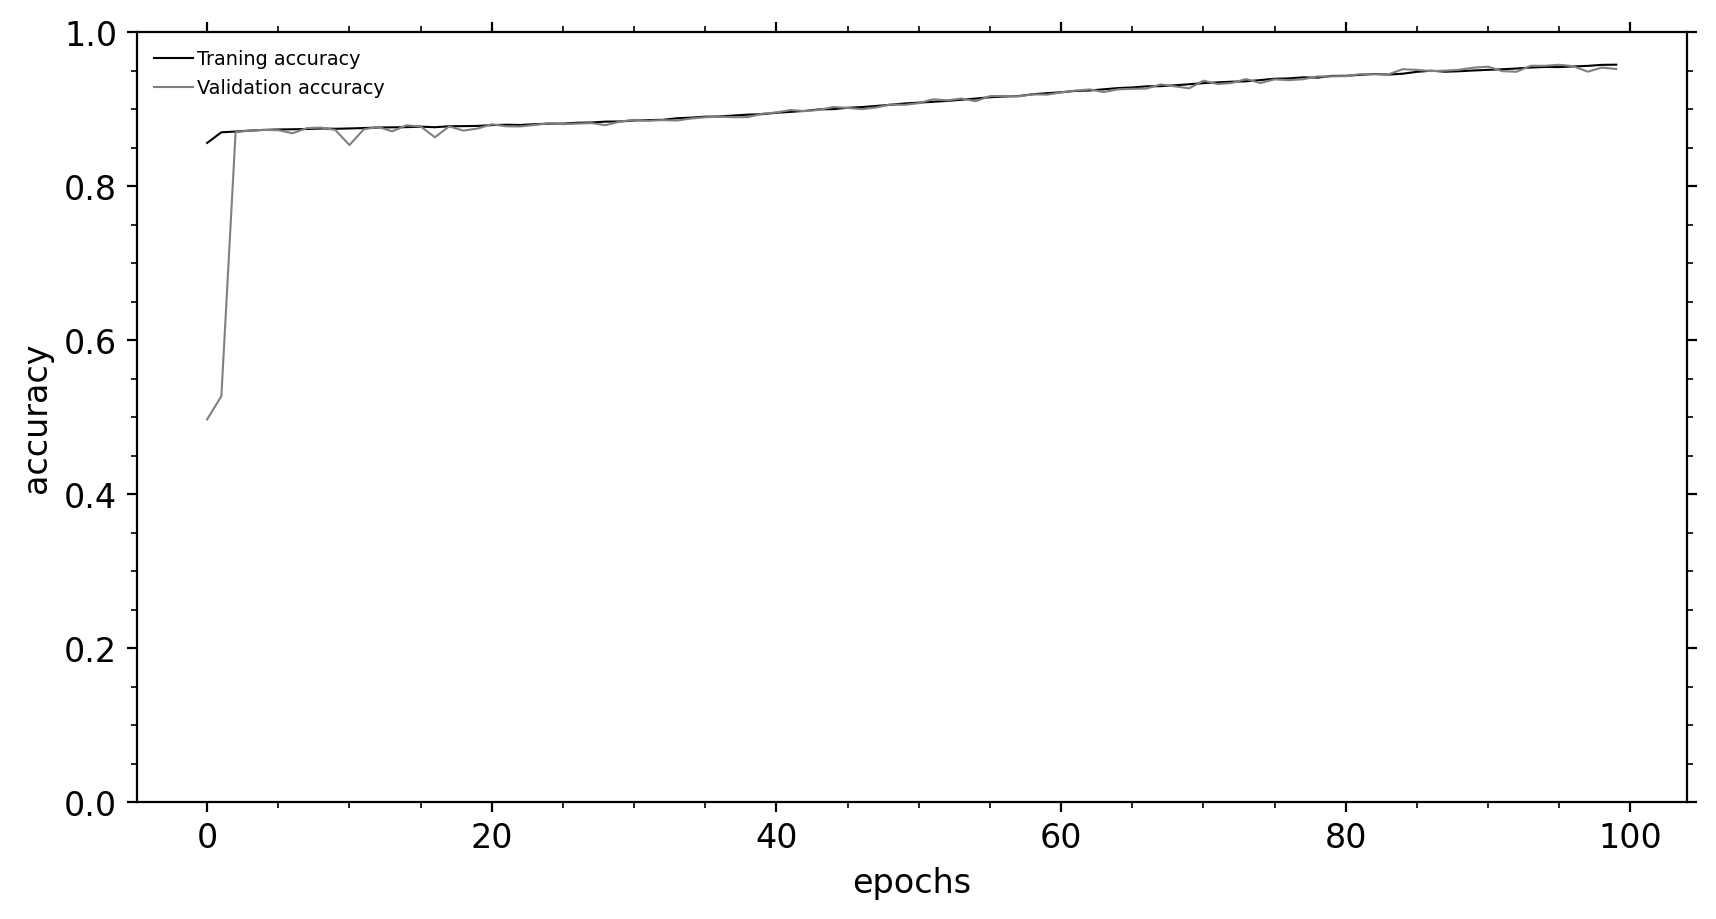

In [237]:
plt.figure(figsize = (10, 5))

plt.plot(train_accuracy, label = "Traning accuracy", color = 'k')
plt.plot(val_accuracy, label = "Validation accuracy", color = "grey")

plt.xlabel("epochs")
plt.ylabel("accuracy")

plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

# plt.title("Traning and Validation Accuracy")
plt.legend()

path = "charts/"
print("Path exists!") if os.path.exists(path) else os.mkdir(path)
count = len(gg(f"{path}/accuracy*.png"))

plt.savefig(os.path.join(path, f"lstm_accuracy_{count}.png"))
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


Path exists!


findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


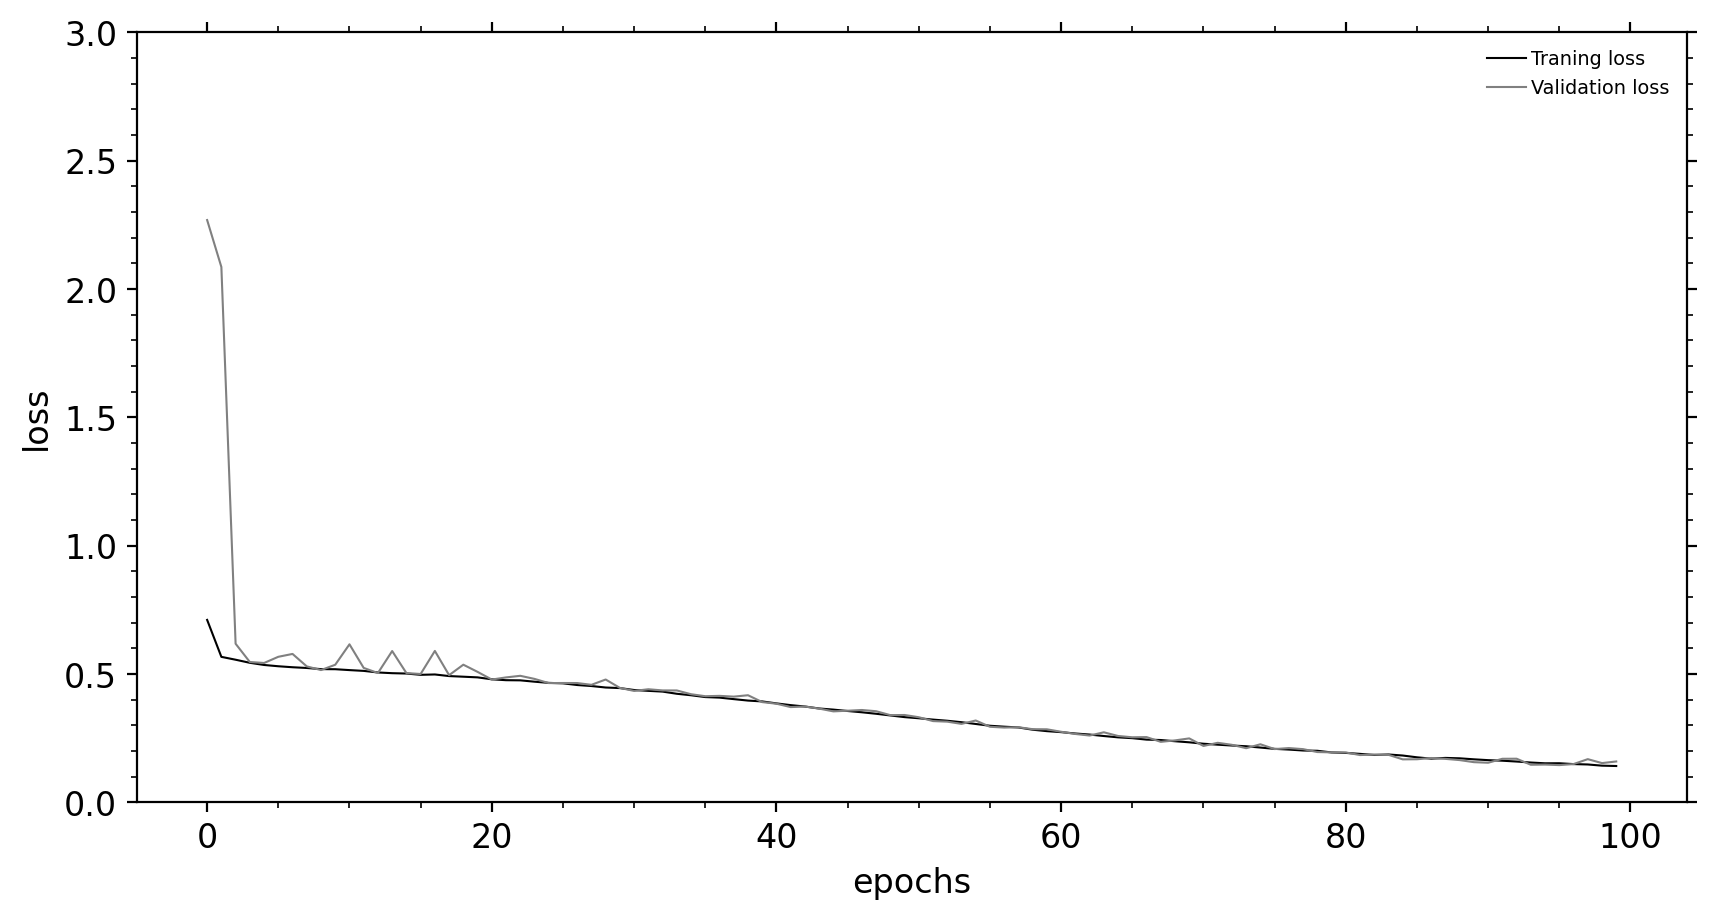

In [241]:
plt.figure(figsize = (10, 5))

plt.plot(train_loss, label = "Traning loss", color = 'k')
plt.plot(val_loss, label = "Validation loss", color = "grey")

plt.xlabel("epochs")
plt.ylabel("loss")

plt.yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])

# plt.title("Traning and Validation loss")
plt.legend()

path = "charts/"
print("Path exists!") if os.path.exists(path) else os.mkdir(path)
count = len(gg(f"{path}/loss*.png"))

plt.savefig(os.path.join(path, f"lstm_loss_{count}.png"))
plt.show()